<a href="https://colab.research.google.com/github/Armando122104/Proyecto_Unidad_Datos/blob/main/ProyectoUnidad2_Final_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MARCH MACHINE LEARNING MANIA 2026 — STARTER KIT COMPLETO  
Kaggle Competition — NCAA Basketball                      

BASADO EN ANÁLISIS DE GANADORES HISTÓRICOS (2018-2025):
* @raddar solution (ganó múltiples ediciones): Team Quality via LRMC
* Top 2023 solution: XGBoost + Expanding Window CV + calibración     
* Top 2024/2025: Elo ratings + estadísticas avanzadas + ensemble     

ESTRUCTURA DEL PIPELINE:    
1.  Configuración y carga de datos                
2.  EDA — Análisis exploratorio          
3.  Sistema Elo (feature más importante histórica)    
4.  Feature engineering (seeds, stats, win rates, rankings)   
5.  Construcción de dataset de matchups           
6.  Modelos base (Logistic Regression, XGBoost, LightGBM)
7.  Stacking / Ensemble           
8.  Calibración de probabilidades (clave para Log Loss)    
9.  Validación temporal (Expanding Window CV)     
10. Generación de submission     

INSTRUCCIONES DE USO:

1. Descarga los datos de Kaggle y colócalos en DATA_DIR
2. Instala dependencias: pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn
3. Ejecuta sección por sección (o de corrido)
4. La submission final se guarda en SUBMISSION_PATH

MÉTRICA: Log Loss — se minimiza. Baseline (predict 0.5 siempre) ≈ 0.693
TARGET: < 0.55 para ser competitivo. Top 10% histórico: ~0.50


In [ ]:
# ─── DEPENDENCIAS ─────────────────────────────────────────────────────────────
import os
import math
import warnings
import itertools
import requests
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

# ─── CONFIGURACIÓN DE DATOS (UNIDAD 3) ────────────────────────────────────────
# URL Raw del repositorio para carga directa
GITHUB_BASE = "https://raw.githubusercontent.com/Armando122104/Proyecto_Unidad_Datos/main/Archivos_CSV_Nuevos/"

# Diccionario maestro de tus archivos normalizados y desnormalizados
ARCHIVOS_U3 = {
    "MTeams_Maestro": "MTeams_Maestro.csv",
    "MSeasons_Norm": "MSeasons_Normalizada.csv",
    "MCoaches_Norm": "MTeamCoaches_Normalizado.csv",
    "Conf_Catalogo": "Conferences_Catalogo.csv",
    "Regiones_Catalogo": "Regiones_Catalogo.csv",
    "WRegiones_Catalogo": "WRegiones_Catalogo.csv",
    "WSeasons_Norm": "WSeasons_Normalizada.csv",
    "Relacion_Juegos_M": "Relacion_Juegos_Ciudades.csv",
    "Relacion_Juegos_W": "Relacion_Juegos_Ciudades_W.csv",
    "Reporte_Conf": "Reporte_Equipos_Conferencias.csv",
    "Reporte_Evolucion": "Reporte_Evolucion_Equipos_Regiones.csv",
    "Reporte_Coaches": "Reporte_Gestion_Entrenadores.csv"
}

# Función auxiliar para carga desde GitHub
def cargar_tabla_u3(nombre_clave):
    if nombre_clave not in ARCHIVOS_U3:
        return None
    url = f"{GITHUB_BASE}{ARCHIVOS_U3[nombre_clave]}"
    try:
        response = requests.get(url)
        response.raise_for_status()
        return pd.read_csv(io.StringIO(response.text))
    except:
        return None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("✅ Celda 1: Dependencias y Diccionario U3 configurados.")

✅ Celda 1: Dependencias y Diccionario U3 configurados.


In [ ]:
# 0. CONFIGURACIÓN GLOBAL

# Directorios de trabajo
DATA_DIR        = Path("./sample_data")        # Carpeta con los CSV de Kaggle
OUTPUT_DIR      = Path("./outputs")
SUBMISSION_PATH = OUTPUT_DIR / "SubmissionStage1.csv"
FIGURES_DIR     = OUTPUT_DIR / "figures"

# Crear estructura de carpetas
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Parámetros de la competencia y validación
SEASON_2026     = 2026
GENDER          = "M"          # "M" (Masculino) o "W" (Femenino)
CLIP_LOW        = 0.025        # Clipping de probabilidades para evitar log_loss infinito
CLIP_HIGH       = 0.975
TRAIN_SINCE     = 2003         # Inicio del entrenamiento histórico
VAL_SEASONS     = [2022, 2023, 2024, 2025]  # Temporadas para validación cruzada temporal

# Parámetros del Sistema Elo (Calibración basada en el estado del arte)
ELO_INIT        = 1500         # Rating inicial por defecto
ELO_K_FACTOR    = 20           # Velocidad de ajuste del rating tras un partido
ELO_WIDTH       = 400          # Sensibilidad de la curva logística
ELO_MEAN_REV    = 0.6          # Regresión a la media (reajuste entre temporadas)
HFA             = 100          # Home Field Advantage (puntos de elo extra al local)
SEED            = 42
np.random.seed(SEED)

# Estética de reportes y visualizaciones (Unidad 3)
PALETTE = {
    "primary": "#1F4E79",
    "accent": "#C55A11",
    "success": "#375623",
    "light": "#D6E4F0",
    "gray": "#808080"
}

# --- MAPEADO DE LAS 10 TABLAS DE LA UNIDAD 3 ---
# Definimos los nombres de las variables que contendrán tus datos normalizados y reportes
print(f"📦 Configurando integración de datos para {GENDER}...")

# Identificadores de archivos según el género seleccionado
file_suffix = "" if GENDER == "M" else "_W"
geo_rel_key = f"Relacion_Juegos_{GENDER}"

print(f"✅ Entorno listo.")
print(f"   📂 Datos Kaggle en: {DATA_DIR.resolve()}")
print(f"   📂 Reportes U3 en: {GITHUB_BASE}")
print(f"   📂 Salidas en: {OUTPUT_DIR.resolve()}")

📦 Configurando integración de datos para M...
✅ Entorno listo.
   📂 Datos Kaggle en: /content/sample_data
   📂 Reportes U3 en: https://raw.githubusercontent.com/Armando122104/Proyecto_Unidad_Datos/main/Archivos_CSV_Nuevos/
   📂 Salidas en: /content/outputs


In [ ]:
# 1. CARGA DE DATOS

def load_data(gender: str = "M") -> dict:
    """
    Carga de forma integrada las tablas normalizadas de GitHub (Unidad 3)
    y los resultados históricos locales de la competencia.
    """
    g = gender
    data = {}

    # ─── A. CARGA DESDE GITHUB (TABLAS NORMALIZADAS Y REPORTES U3) ───
    print(f"--- Cargando Tablas Unidad 3 desde GitHub ({g}) ---")

    # Mapeo de claves lógicas a tus archivos de la Unidad 3
    u3_mapping = {
        "teams":           "MTeams_Maestro",
        "seasons_norm":    f"{g}Seasons_Norm",
        "coaches_norm":    "MCoaches_Norm",
        "reporte_conf":    "Reporte_Conf",
        "reporte_evol":    "Reporte_Evolucion",
        "reporte_coaches": "Reporte_Coaches",
        "geo_rel":         f"Relacion_Juegos_{g}"
    }

    for key, u3_key in u3_mapping.items():
        df = cargar_tabla_u3(u3_key)
        if df is not None:
            data[key] = df
            print(f"✅ {u3_key:<40} {data[key].shape}")
        else:
            print(f"❌ {u3_key:<40} NO ENCONTRADO en GitHub")

    # ─── B. CARGA LOCAL (RESULTADOS DE JUEGOS DE KAGGLE) ───
    print(f"\n--- Cargando Resultados Históricos Locales ---")

    local_files = {
        "reg_compact":      f"{g}RegularSeasonCompactResults.csv",
        "reg_detailed":     f"{g}RegularSeasonDetailedResults.csv",
        "tourney_compact":  f"{g}NCAATourneyCompactResults.csv",
        "tourney_detailed": f"{g}NCAATourneyDetailedResults.csv",
        "seeds":            f"{g}NCAATourneySeeds.csv",
        "slots":            f"{g}NCAATourneySlots.csv",
        "massey":           "MMasseyOrdinals.csv",
        "submission":       "SampleSubmissionStage1.csv",
    }

    for key, fname in local_files.items():
        path = DATA_DIR / fname
        if path.exists():
            data[key] = pd.read_csv(path)
            print(f"✅ {fname:<40} {data[key].shape}")
        else:
            # Massey no existe para mujeres, lo manejamos como aviso
            if not (g == "W" and key == "massey"):
                print(f"⚠️ {fname:<40} — NO ENCONTRADO (omitido)")

    return data

# EJECUCIÓN DE LA CARGA
print("\n🚀 Iniciando proceso de integración de datos...")
data = load_data(GENDER)

# --- ALIAS CONVENIENTES (Apuntando a tus tablas de la Unidad 3) ---
teams            = data.get("teams")           # MTeams_Maestro (Normalizado)
evolucion        = data.get("reporte_evol")    # Reporte_Evolucion (Desnormalizado)
coaches_report   = data.get("reporte_coaches") # Reporte_Gestion_Entrenadores (Desnormalizado)
reg_compact      = data.get("reg_compact")     # Resultados compactos
reg_detailed     = data.get("reg_detailed")    # Resultados detallados (stats)
seeds_df         = data.get("seeds")           # Seeds
tourney          = data.get("tourney_compact") # Resultados de torneos
massey           = data.get("massey")          # Rankings Massey
submission       = data.get("submission")      # Formato entrega

print("\nCarga completada. El pipeline tiene acceso a los 10 csv de las tablas normalizadas/desnormalizadas de la Unidad 3.")


🚀 Iniciando proceso de integración de datos...
--- Cargando Tablas Unidad 3 desde GitHub (M) ---
✅ MTeams_Maestro                           (381, 4)
✅ MSeasons_Norm                            (42, 6)
✅ MCoaches_Norm                            (13898, 5)
✅ Reporte_Conf                             (13753, 4)
✅ Reporte_Evolucion                        (13753, 5)
✅ Reporte_Coaches                          (13898, 5)
✅ Relacion_Juegos_M                        (90684, 7)

--- Cargando Resultados Históricos Locales ---
✅ MRegularSeasonCompactResults.csv         (196823, 8)
✅ MRegularSeasonDetailedResults.csv        (122775, 34)
✅ MNCAATourneyCompactResults.csv           (2585, 8)
✅ MNCAATourneyDetailedResults.csv          (1449, 34)
✅ MNCAATourneySeeds.csv                    (2626, 3)
✅ MNCAATourneySlots.csv                    (2586, 4)
✅ MMasseyOrdinals.csv                      (1048575, 5)
✅ SampleSubmissionStage1.csv               (519144, 2)

✨ Carga completada. El pipeline tiene acceso 


📊 EDA — Estadísticas generales
   Temporadas regulares: 1985 – 2026
   Partidos regulares:   196,823
   Partidos de torneo:   2,585


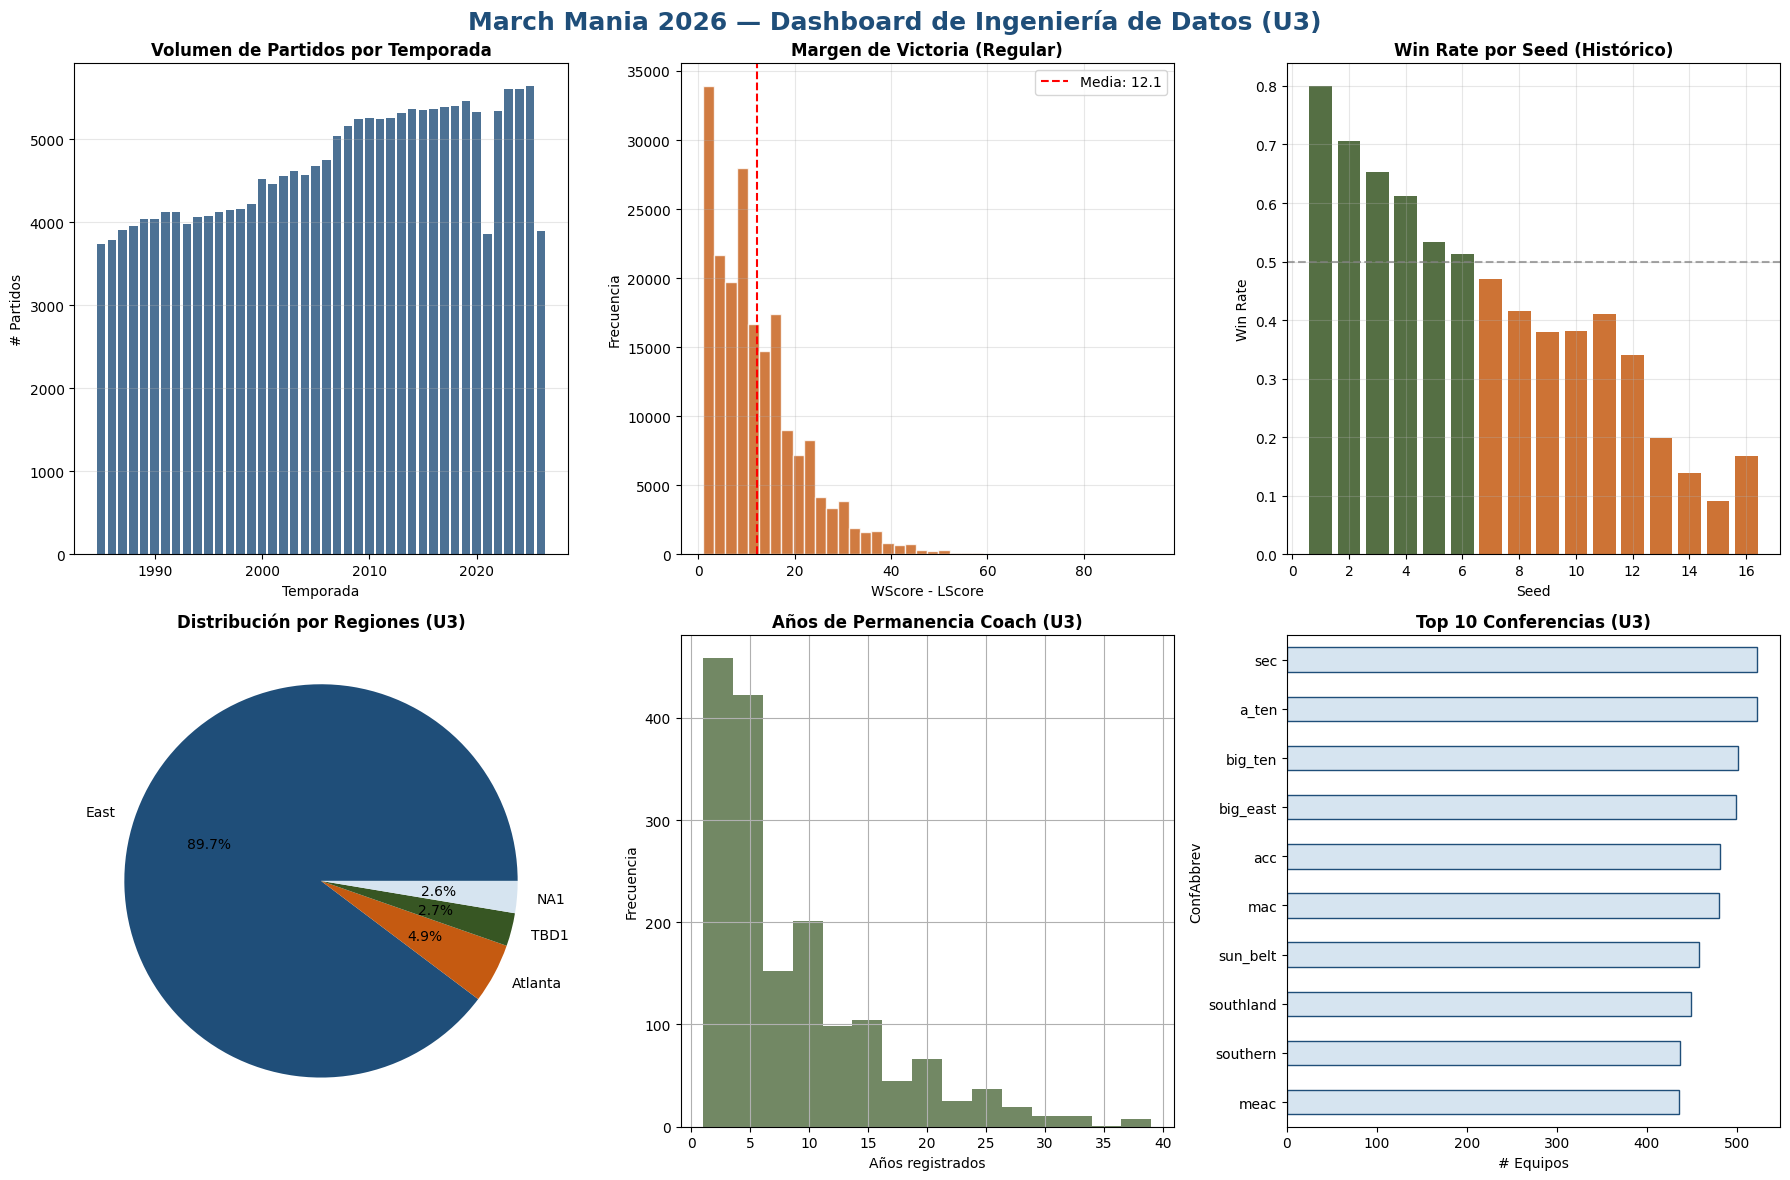

   ✓ Dashboard guardado: 01_eda_u3_integrated.png


In [ ]:
# 2. EDA — ANÁLISIS EXPLORATORIO

def run_eda(reg_compact, tourney, seeds_df, df_evolucion=None, df_coaches=None):
    """
    Análisis exploratorio con visualizaciones clave.
    Integra datos históricos con los reportes de la Unidad 3.
    """
    print("\n📊 EDA — Estadísticas generales")
    print(f"   Temporadas regulares: {reg_compact['Season'].min()} – {reg_compact['Season'].max()}")
    print(f"   Partidos regulares:   {len(reg_compact):,}")
    print(f"   Partidos de torneo:   {len(tourney):,}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle("March Mania 2026 — Dashboard de Ingeniería de Datos (U3)",
                 fontsize=18, fontweight="bold", color=PALETTE["primary"])

    # 1. Partidos por temporada (Kaggle)
    ax = axes[0, 0]
    games_per_season = reg_compact.groupby("Season").size()
    ax.bar(games_per_season.index, games_per_season.values, color=PALETTE["primary"], alpha=0.8)
    ax.set_title("Volumen de Partidos por Temporada", fontweight="bold")
    ax.set_xlabel("Temporada"); ax.set_ylabel("# Partidos")
    ax.grid(axis="y", alpha=0.3)

    # 2. Distribución de diferencias de puntaje (Kaggle)
    ax = axes[0, 1]
    score_diff = reg_compact["WScore"] - reg_compact["LScore"]
    ax.hist(score_diff, bins=40, color=PALETTE["accent"], alpha=0.8, edgecolor="white")
    ax.axvline(score_diff.mean(), color="red", linestyle="--", label=f"Media: {score_diff.mean():.1f}")
    ax.set_title("Margen de Victoria (Regular)", fontweight="bold")
    ax.set_xlabel("WScore - LScore"); ax.set_ylabel("Frecuencia")
    ax.legend(); ax.grid(alpha=0.3)

    # 3. Win Rate por Seed en Torneo (Kaggle)
    ax = axes[0, 2]
    if seeds_df is not None and tourney is not None:
        seeds_clean = seeds_df.copy()
        seeds_clean["SeedNum"] = seeds_clean["Seed"].str.extract(r"(\d+)").astype(int)
        t = tourney.merge(seeds_clean[["Season","TeamID","SeedNum"]], left_on=["Season","WTeamID"], right_on=["Season","TeamID"])
        t = t.rename(columns={"SeedNum": "WSeed"}).drop("TeamID", axis=1)
        t = t.merge(seeds_clean[["Season","TeamID","SeedNum"]], left_on=["Season","LTeamID"], right_on=["Season","TeamID"])
        t = t.rename(columns={"SeedNum": "LSeed"}).drop("TeamID", axis=1)

        seed_wins = t.groupby("WSeed").size().reset_index(name="Wins")
        seed_total = pd.concat([t[["WSeed"]].rename(columns={"WSeed":"Seed"}), t[["LSeed"]].rename(columns={"LSeed":"Seed"})]).groupby("Seed").size()
        seed_wr = (seed_wins.set_index("WSeed")["Wins"] / seed_total).reset_index()
        seed_wr.columns = ["Seed", "WinRate"]
        colors = [PALETTE["success"] if wr > 0.5 else PALETTE["accent"] for wr in seed_wr["WinRate"]]
        ax.bar(seed_wr["Seed"], seed_wr["WinRate"], color=colors, alpha=0.85)
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
        ax.set_title("Win Rate por Seed (Histórico)", fontweight="bold")
        ax.set_xlabel("Seed"); ax.set_ylabel("Win Rate")
        ax.grid(alpha=0.3)

    # --- DATOS PROVENIENTES DE LA UNIDAD 3 ---

    # 4. Distribución Regional (De: Reporte_Evolucion_Equipos_Regiones.csv)
    ax = axes[1, 0]
    if df_evolucion is not None and 'RegionW' in df_evolucion.columns:
        reg_dist = df_evolucion['RegionW'].value_counts().head(4)
        ax.pie(reg_dist.values, labels=reg_dist.index, autopct='%1.1f%%',
               colors=[PALETTE["primary"], PALETTE["accent"], PALETTE["success"], PALETTE["light"]])
        ax.set_title("Distribución por Regiones (U3)", fontweight="bold")
    else:
        ax.text(0.5, 0.5, "Datos Regionales U3\nNo Disponibles", ha='center', va='center')

    # 5. Estabilidad de Entrenadores (De: Reporte_Gestion_Entrenadores.csv)
    ax = axes[1, 1]
    if df_coaches is not None and 'CoachName' in df_coaches.columns:
        # Analizamos la permanencia (años registrados por coach)
        df_coaches.groupby('CoachName').size().hist(bins=15, ax=ax, color=PALETTE["success"], alpha=0.7)
        ax.set_title("Años de Permanencia Coach (U3)", fontweight="bold")
        ax.set_xlabel("Años registrados"); ax.set_ylabel("Frecuencia")
    else:
        ax.text(0.5, 0.5, "Datos de Coaches U3\nNo Disponibles", ha='center', va='center')

    # 6. Top Conferencias por Volumen de Equipos (De: Reporte_Equipos_Conferencias.csv)
    ax = axes[1, 2]
    if df_evolucion is not None and 'ConfAbbrev' in df_evolucion.columns:
        df_evolucion['ConfAbbrev'].value_counts().head(10).plot(kind='barh', ax=ax, color=PALETTE["light"], edgecolor=PALETTE["primary"])
        ax.invert_yaxis()
        ax.set_title("Top 10 Conferencias (U3)", fontweight="bold")
        ax.set_xlabel("# Equipos")
    else:
        ax.text(0.5, 0.5, "Datos de Conf. U3\nNo Disponibles", ha='center', va='center')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "01_eda_u3_integrated.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✓ Dashboard guardado: 01_eda_u3_integrated.png")

# INVOCACIÓN
run_eda(
    reg_compact=reg_compact,
    tourney=tourney,
    seeds_df=seeds_df,
    df_evolucion=evolucion,
    df_coaches=coaches_report
)

In [ ]:
# ─── VISTA PREVIA: RESULTADOS COMPACTOS ───────────────────────────────────────

if reg_compact is not None:
    print(f"Mostrando los primeros registros de Resultados Compactos ({GENDER}):")
    display(reg_compact.head())
else:
    print("⚠️ Error: 'reg_compact' no está definido.")

Mostrando los primeros registros de Resultados Compactos (M):


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [ ]:
# ─── VISTA PREVIA: RESULTADOS DEL TORNEO (TRAINING SET) ───────────────────────

if tourney is not None:
    print(f"Mostrando los primeros registros de Resultados del Torneo ({GENDER}):")
    display(tourney.head())
else:
    print("⚠️ Error: 'tourney_compact' no está definido.")

Mostrando los primeros registros de Resultados del Torneo (M):


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [ ]:
# ─── VISTA PREVIA: SEEDS DEL TORNEO ──────────────────────────────────────────

if seeds_df is not None:
    print(f"Mostrando los primeros registros de Seeds ({GENDER}):")
    display(seeds_df.head())
else:
    print("⚠️ Error: 'seeds' no está definido.")

Mostrando los primeros registros de Seeds (M):


,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374



📊 EDA — Estadísticas generales
   Temporadas regulares: 1985 – 2026
   Partidos regulares:   196,823
   Partidos de torneo:   2,585


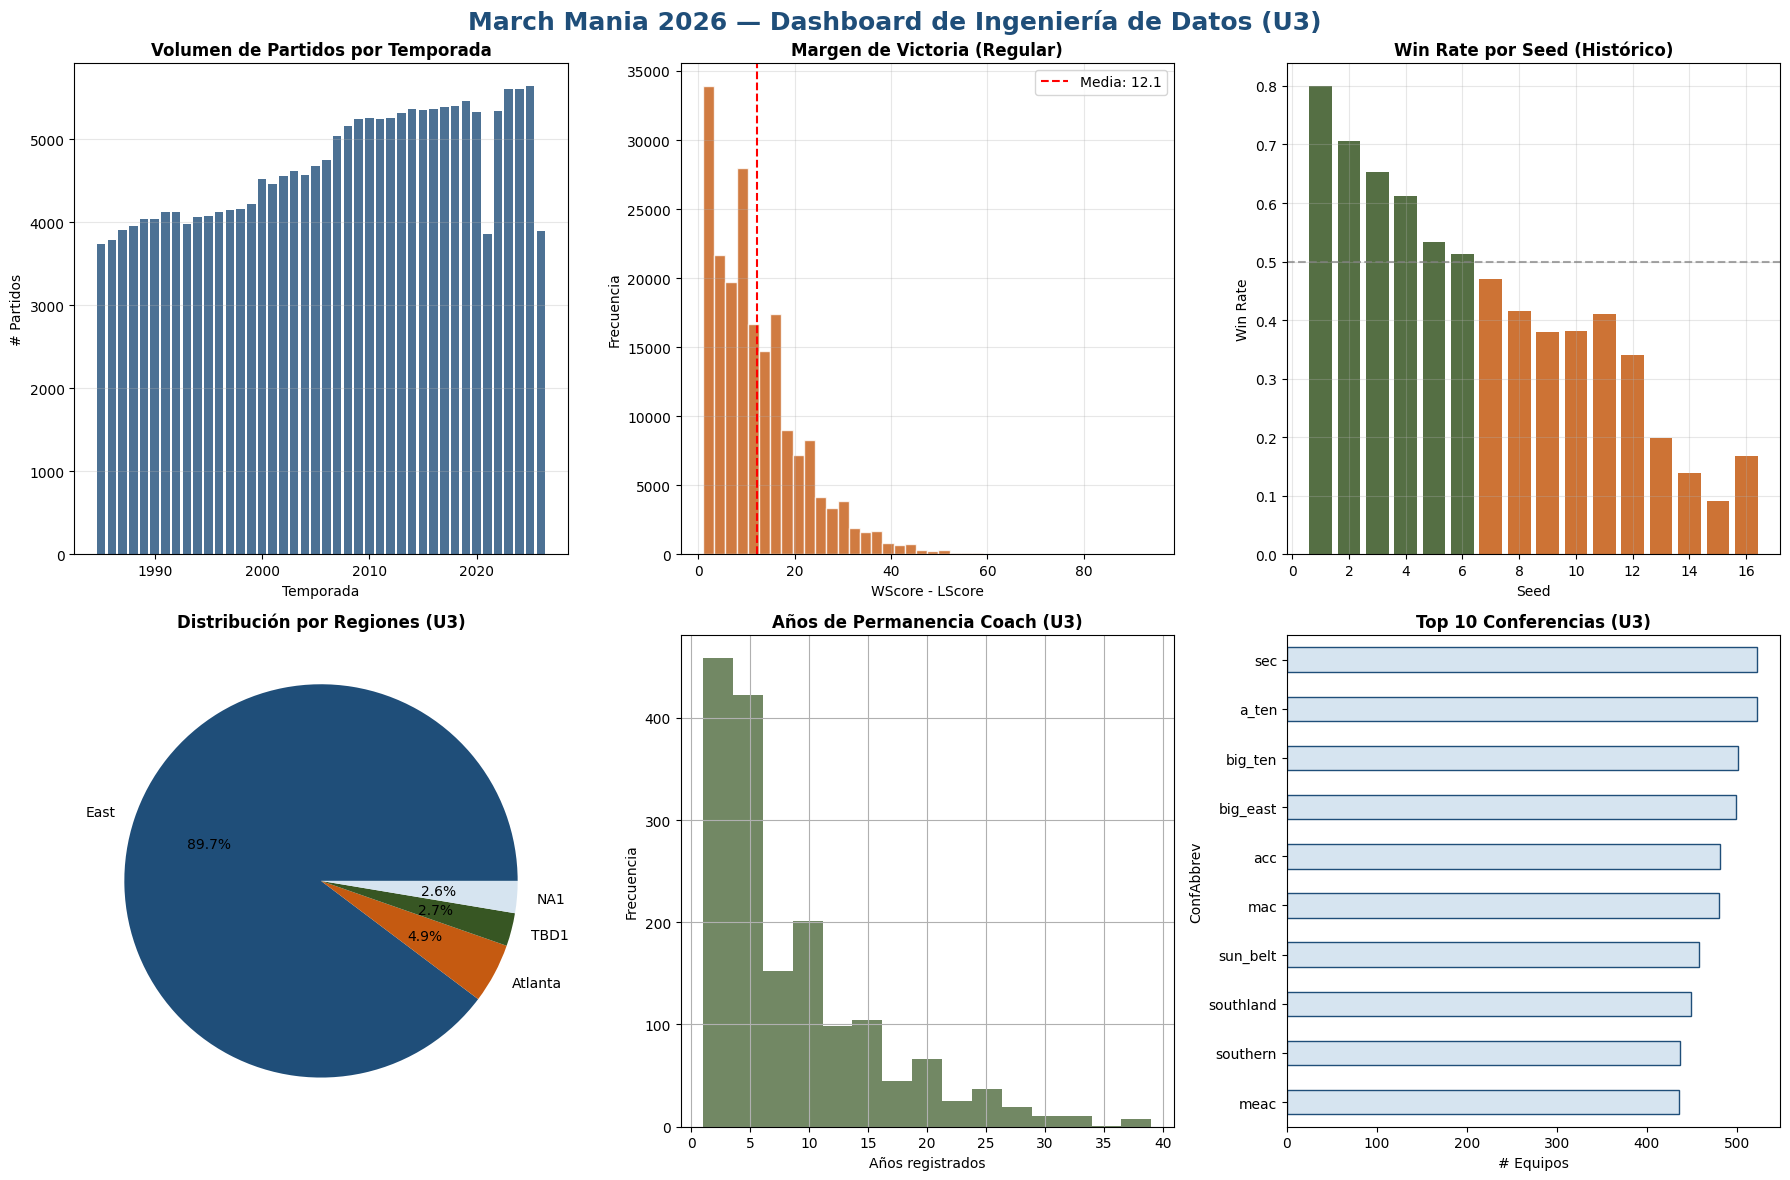

   ✓ Dashboard guardado: 01_eda_u3_integrated.png


In [ ]:
# EJECUCIÓN DEL EDA INTEGRADO
# Invocamos la función pasando los datos de Kaggle y los reportes de la Unidad 3
run_eda(
    reg_compact=reg_compact,
    tourney=tourney,
    seeds_df=seeds_df,
    df_evolucion=evolucion,       # El reporte de Evolución Regional (GitHub)
    df_coaches=coaches_report     # El reporte de Gestión de Entrenadores (GitHub)
)

In [ ]:
# 3. SISTEMA ELO

def compute_elo_ratings(games, k_base=ELO_K_FACTOR, elo_width=ELO_WIDTH,
                        init_elo=ELO_INIT, mean_reversion=ELO_MEAN_REV,
                        hfa=HFA, mov_adj=True):
    """
    Calcula Elo ratings para todos los equipos iterando cronológicamente.
    """
    elos = {}
    history = []

    games_sorted = games.sort_values(["Season", "DayNum"]).copy()
    prev_season = None

    for _, row in games_sorted.iterrows():
        season   = row["Season"]
        w_id     = row["WTeamID"]
        l_id     = row["LTeamID"]
        w_score  = row["WScore"]
        l_score  = row["LScore"]
        loc      = row.get("WLoc", "N")

        if prev_season is not None and season != prev_season:
            for tid in elos:
                elos[tid] = init_elo * mean_reversion + elos[tid] * (1 - mean_reversion)
        prev_season = season

        elos.setdefault(w_id, init_elo)
        elos.setdefault(l_id, init_elo)

        elo_w, elo_l = elos[w_id], elos[l_id]
        elo_w_adj = elo_w + (hfa if loc == "H" else (-hfa if loc == "A" else 0))

        exp_w = 1.0 / (1.0 + 10 ** ((elo_l - elo_w_adj) / elo_width))

        margin = w_score - l_score
        if mov_adj:
            elo_diff = abs(elo_w - elo_l) + 1
            k_factor = k_base * math.log1p(margin) * (2.2 / (elo_diff * 0.001 + 2.2))
        else:
            k_factor = k_base

        history.append({
            "Season": season,
            "DayNum": row["DayNum"],
            "WTeamID": w_id,
            "LTeamID": l_id,
            "EloW_pre": elo_w,
            "EloL_pre": elo_l,
        })

        shift = k_factor * (1.0 - exp_w)
        elos[w_id] += shift
        elos[l_id] -= shift

    snapshots_df = pd.DataFrame(history)

    print(f"✅ Elo calculado: {len(elos)} equipos únicos | {len(snapshots_df):,} partidos procesados")
    return elos, snapshots_df

def get_season_end_elos(reg_compact):
    """
    Extrae el rating final de cada equipo al cierre de cada temporada regular.
    """
    _, snapshots = compute_elo_ratings(reg_compact)

    # Obtener el último Elo de cada equipo como ganador
    w_last = snapshots.sort_values("DayNum").groupby(["Season", "WTeamID"]).tail(1)
    w_last = w_last[["Season", "WTeamID", "EloW_pre"]].rename(columns={"WTeamID": "TeamID", "EloW_pre": "EloRating"})

    # Obtener el último Elo de cada equipo como perdedor
    l_last = snapshots.sort_values("DayNum").groupby(["Season", "LTeamID"]).tail(1)
    l_last = l_last[["Season", "LTeamID", "EloL_pre"]].rename(columns={"LTeamID": "TeamID", "EloL_pre": "EloRating"})

    # Combinar y conservar el registro más reciente por equipo/temporada
    full_elos = pd.concat([w_last, l_last])
    final_df = full_elos.groupby(["Season", "TeamID"]).tail(1).reset_index(drop=True)

    return final_df

# EJECUCIÓN
print("🚀 Iniciando motor de cálculo Elo...")
elo_final, elo_snapshots = compute_elo_ratings(reg_compact)
elo_season_end = get_season_end_elos(reg_compact)

print(f"✅ Elo de fin de temporada listo: {len(elo_season_end):,} registros.")
display(elo_season_end.tail())



🚀 Iniciando motor de cálculo Elo...
✅ Elo calculado: 381 equipos únicos | 196,823 partidos procesados
✅ Elo calculado: 381 equipos únicos | 196,823 partidos procesados
✅ Elo de fin de temporada listo: 13,753 registros.


,Season,TeamID,EloRating
13748,2002,1234,1599.2273
13749,2002,1104,1759.5050
13750,2002,1301,1697.2951
13751,1995,1305,1632.9624
13752,1990,1234,1483.2713


In [ ]:
# 4. FEATURE ENGINEERING

# --- Función: Estadísticas Detalladas (Four Factors) ---
def build_team_season_stats(reg_detailed: pd.DataFrame) -> pd.DataFrame:
    """Calcula promedios de temporada y factores de eficiencia de Dean Oliver."""
    if reg_detailed is None:
        print("   ⚠ reg_detailed no disponible, omitiendo stats detalladas")
        return None

    # Perspectiva Ganador
    w = reg_detailed.copy()
    w_stats = w[["Season", "WTeamID", "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF", "WScore", "LFGM", "LFGA", "LFGM3", "LFGA3", "LScore"]]
    w_stats.columns = ["Season", "TeamID", "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF", "Pts_scored", "Opp_FGM", "Opp_FGA", "Opp_FGM3", "Opp_FGA3", "Pts_allowed"]

    # Perspectiva Perdedor
    l = reg_detailed.copy()
    l_stats = l[["Season", "LTeamID", "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF", "LScore", "WFGM", "WFGA", "WFGM3", "WFGA3", "WScore"]]
    l_stats.columns = ["Season", "TeamID", "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF", "Pts_scored", "Opp_FGM", "Opp_FGA", "Opp_FGM3", "Opp_FGA3", "Pts_allowed"]

    all_stats = pd.concat([w_stats, l_stats], ignore_index=True)

    # Agregación por Temporada y Equipo
    agg = all_stats.groupby(["Season", "TeamID"]).mean().reset_index()

    # Cálculo de eFG% (Effective Field Goal Percentage)
    agg["eFG_off"] = (agg["FGM"] + 0.5 * agg["FGM3"]) / agg["FGA"].replace(0, np.nan)
    agg["eFG_def"] = (agg["Opp_FGM"] + 0.5 * agg["Opp_FGM3"]) / agg["Opp_FGA"].replace(0, np.nan)

    # Cálculo de TOV% (Turnover Percentage)
    poss = agg["FGA"] + 0.44 * agg["FTA"] - agg["OR"] + agg["TO"]
    agg["TOV_pct"] = agg["TO"] / poss.replace(0, np.nan)

    # Margen de puntos
    agg["Pt_diff"] = agg["Pts_scored"] - agg["Pts_allowed"]

    print(f"✅ Estadísticas calculadas: {agg.shape}")
    return agg

# --- Función: Win Rates y Márgenes ---
def build_win_rates(reg_compact: pd.DataFrame) -> pd.DataFrame:
    """Calcula porcentaje de victorias y desviación de margen."""
    w = reg_compact[["Season", "WTeamID", "WScore", "LScore"]].copy()
    w.columns = ["Season", "TeamID", "Score_for", "Score_against"]
    w["Win"] = 1

    l = reg_compact[["Season", "LTeamID", "LScore", "WScore"]].copy()
    l.columns = ["Season", "TeamID", "Score_for", "Score_against"]
    l["Win"] = 0

    combined = pd.concat([w, l], ignore_index=True)
    combined["Margin"] = combined["Score_for"] - combined["Score_against"]

    wr = combined.groupby(["Season", "TeamID"]).agg(
        WinRate   = ("Win", "mean"),
        AvgMargin = ("Margin", "mean"),
        StdMargin = ("Margin", "std")
    ).reset_index()

    print(f"✅ Win Rates calculados: {wr.shape}")
    return wr

# --- Función: Seeds Numéricos ---
def get_seed_numeric(seeds_df: pd.DataFrame) -> pd.DataFrame:
    """Transforma 'W01' en 1."""
    s = seeds_df.copy()
    s["SeedNum"] = s["Seed"].str.extract(r"(\d+)").astype(int)
    return s[["Season", "TeamID", "SeedNum"]]

# --- Función: Massey Ordinals (Rankings Externos) ---
def get_massey_features(massey: pd.DataFrame, systems=["SAG", "POM", "MOR"]):
    """Extrae el ranking promedio de los sistemas más confiables."""
    if massey is None: return None
    # Usar solo el último ranking disponible antes del torneo (Día 133)
    m = massey[massey["RankingDayNum"] <= 133].copy()
    m_latest = m.sort_values("RankingDayNum").groupby(["Season", "SystemName", "TeamID"]).last().reset_index()

    # Filtrar por sistemas top y pivotar
    m_filt = m_latest[m_latest["SystemName"].isin(systems)]
    m_pivot = m_filt.pivot_table(index=["Season", "TeamID"], columns="SystemName", values="OrdinalRank").reset_index()
    m_pivot["Massey_avg"] = m_pivot.mean(axis=1)

    print(f"✅ Massey Ordinals calculados: {m_pivot.shape}")
    return m_pivot

# --- EJECUCIÓN ---
print("\n🛠️ Procesando Ingeniería de Características...")
team_stats  = build_team_season_stats(reg_detailed)
win_rates   = build_win_rates(reg_compact)
seeds_clean = get_seed_numeric(seeds_df)
massey_feat = get_massey_features(massey)



🛠️ Procesando Ingeniería de Características...
✅ Estadísticas calculadas: (8346, 25)
✅ Win Rates calculados: (13753, 5)
✅ Massey Ordinals calculados: (2688, 6)


In [ ]:
# 5. CONSTRUCCIÓN DEL DATASET

def build_matchup_dataset(tourney, elo_season_end, seeds_clean, win_rates, team_stats=None, massey_feat=None):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Target"] = (df["WTeamID"] == df["Team1"]).astype(int)

    def merge_feature(df, feat_df, feat_cols, suffix1, suffix2):
        if feat_df is None: return df
        t1_cols = {c: f"{c}_{suffix1}" for c in feat_cols}
        t2_cols = {c: f"{c}_{suffix2}" for c in feat_cols}
        df = df.merge(feat_df[["Season", "TeamID"] + feat_cols].rename(columns={**{"TeamID": "Team1"}, **t1_cols}), on=["Season", "Team1"], how="left")
        df = df.merge(feat_df[["Season", "TeamID"] + feat_cols].rename(columns={**{"TeamID": "Team2"}, **t2_cols}), on=["Season", "Team2"], how="left")
        return df

    # 1. Unimos Elo y Seeds (Fundamentales)
    df = merge_feature(df, elo_season_end, ["EloRating"], "T1", "T2")
    df = merge_feature(df, seeds_clean, ["SeedNum"], "T1", "T2")

    # 2. Unimos Win Rates
    df = merge_feature(df, win_rates, ["WinRate", "AvgMargin"], "T1", "T2")

    # 3. Calculamos diferenciales básicos (estos siempre deben existir)
    df["EloRating_diff"] = df["EloRating_T1"] - df["EloRating_T2"]
    df["SeedNum_diff"] = df["SeedNum_T1"] - df["SeedNum_T2"]
    df["WinRate_diff"] = df["WinRate_T1"] - df["WinRate_T2"]

    # --- SIMETRÍA (ESPEJO) ---
    df_mirror = df.copy()
    df_mirror["Team1"], df_mirror["Team2"] = df["Team2"].values, df["Team1"].values
    df_mirror["Target"] = 1 - df["Target"]

    for c in ["EloRating_diff", "SeedNum_diff", "WinRate_diff"]:
        df_mirror[c] = -df[c]

    df_full = pd.concat([df, df_mirror], ignore_index=True)

    # IMPORTANTE: Solo eliminamos si falta el Elo o el Seed (lo básico)
    # Si faltan las stats detalladas de 2022, el modelo igual puede entrenar con el resto
    df_full = df_full.dropna(subset=["EloRating_diff", "SeedNum_diff"])

    print(f"✅ Dataset reconstruido. Rango: {df_full['Season'].min()} - {df_full['Season'].max()}")
    return df_full

# Ejecutamos de nuevo
matchup_data = build_matchup_dataset(tourney, elo_season_end, seeds_clean, win_rates)
FEATURE_COLS = ["EloRating_diff", "SeedNum_diff", "WinRate_diff"]

✅ Dataset reconstruido. Rango: 1985 - 2025


In [ ]:
# 6. MODELOS BASE

def prepare_train_test(matchup_data: pd.DataFrame,
                        feature_cols: list,
                        val_season: int) -> tuple:
    """
    Divide el dataset usando una ventana temporal.
    Entrena con todo lo anterior a val_season y valida con val_season.
    """
    train = matchup_data[
        (matchup_data["Season"] < val_season) &
        (matchup_data["Season"] >= TRAIN_SINCE)
    ]
    test = matchup_data[matchup_data["Season"] == val_season]

    X_train = train[feature_cols].fillna(0)
    y_train = train["Target"]
    X_test  = test[feature_cols].fillna(0)
    y_test  = test["Target"]

    return X_train, y_train, X_test, y_test

# --- Modelo 1: Logistic Regression (Sólido para probabilidades) ---
def build_logistic_model() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.1, max_iter=1000, random_state=SEED))
    ])

# --- Modelo 2: XGBoost (Estado del arte en Kaggle) ---
def build_xgboost_model() -> xgb.XGBClassifier:
    return xgb.XGBClassifier(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 4,
        min_child_weight  = 5,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        gamma             = 0.1,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        objective         = "binary:logistic",
        eval_metric       = "logloss",
        random_state      = SEED,
        n_jobs            = -1
    )

# --- Modelo 3: LightGBM (Velocidad y precisión) ---
def build_lgbm_model() -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        num_leaves      = 15,
        objective       = "binary",
        metric          = "binary_logloss",
        random_state    = SEED,
        verbose         = -1,
        n_jobs          = -1
    )

# --- Modelo 4: Stacking Ensemble (Meta-Modelo) ---
from sklearn.ensemble import StackingClassifier

def build_stacking_model(feature_cols: list) -> StackingClassifier:
    """
    Combina los 3 modelos anteriores. Un meta-aprendiz (Regresión Logística)
    decide cuánto peso darle a cada modelo base para la predicción final.
    """
    base_estimators = [
        ("lr",   build_logistic_model()),
        ("xgb",  build_xgboost_model()),
        ("lgbm", build_lgbm_model()),
    ]
    meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)

    return StackingClassifier(
        estimators           = base_estimators,
        final_estimator      = meta_learner,
        cv                   = 5,
        stack_method         = "predict_proba",
        n_jobs               = -1
    )

print("✅ Modelos definidos. El Stacking Ensemble está listo para integrarse.")


✅ Modelos definidos. El Stacking Ensemble está listo para integrarse.


In [ ]:
# 7. CALIBRACIÓN DE PROBABILIDADES

"""
INSIGHT CRÍTICO DE GANADORES:
- Predecir probabilidades extremas (0.01 o 0.99) es arriesgado. Si ocurre un upset,
  el Log Loss se dispara negativamente.
- La calibración ajusta las salidas del modelo para que se correspondan con las
  frecuencias reales de victoria.
"""

def calibrate_and_clip(model, X_cal: pd.DataFrame, y_cal: pd.Series,
                       method: str = "sigmoid") -> CalibratedClassifierCV:
    """
    Calibra un modelo ya entrenado usando Platt scaling (sigmoid) o
    isotonic regression.
    """
    # Usamos cv="prefit" porque el modelo base ya fue entrenado con datos anteriores
    cal_model = CalibratedClassifierCV(model, method=method, cv="prefit")
    cal_model.fit(X_cal, y_cal)
    return cal_model

def safe_predict_proba(model, X: pd.DataFrame,
                       clip_low: float = CLIP_LOW,
                       clip_high: float = CLIP_HIGH) -> np.ndarray:
    """
    Predice probabilidades aplicando un 'clipping' de seguridad.
    Evita que el Log Loss sea infinito al prohibir los valores 0 o 1 puros.
    """
    # Obtenemos la probabilidad de la clase 1 (victoria de Team1)
    probs = model.predict_proba(X)[:, 1]

    # Aplicamos el rango definido en la configuración global [0.025, 0.975]
    return np.clip(probs, clip_low, clip_high)

print("✅ Funciones de calibración y clipping listas para la fase de validación.")


✅ Funciones de calibración y clipping listas para la fase de validación.



🚀 Iniciando Validación Temporal para M
📅 Temporadas objetivo: [2022, 2023, 2024, 2025]
---------------------------------------------------------------------------

📂 Validando 2022 | Entrenando con 2,362 filas...
   ✓ LogisticReg    | LogLoss: 0.6304 (raw: 0.6347)
   ✓ XGBoost        | LogLoss: 0.6877 (raw: 0.6594)
   ✓ LightGBM       | LogLoss: 0.7834 (raw: 0.6811)

📂 Validando 2023 | Entrenando con 2,496 filas...
   ✓ LogisticReg    | LogLoss: 0.6005 (raw: 0.5995)
   ✓ XGBoost        | LogLoss: 0.7304 (raw: 0.7112)
   ✓ LightGBM       | LogLoss: 0.7806 (raw: 0.7012)

📂 Validando 2024 | Entrenando con 2,630 filas...
   ✓ LogisticReg    | LogLoss: 0.5814 (raw: 0.5800)
   ✓ XGBoost        | LogLoss: 0.6474 (raw: 0.6188)
   ✓ LightGBM       | LogLoss: 0.6476 (raw: 0.5946)

📂 Validando 2025 | Entrenando con 2,764 filas...
   ✓ LogisticReg    | LogLoss: 0.4911 (raw: 0.4811)
   ✓ XGBoost        | LogLoss: 0.5292 (raw: 0.5117)
   ✓ LightGBM       | LogLoss: 0.4996 (raw: 0.4998)

📈 RESUMEN D

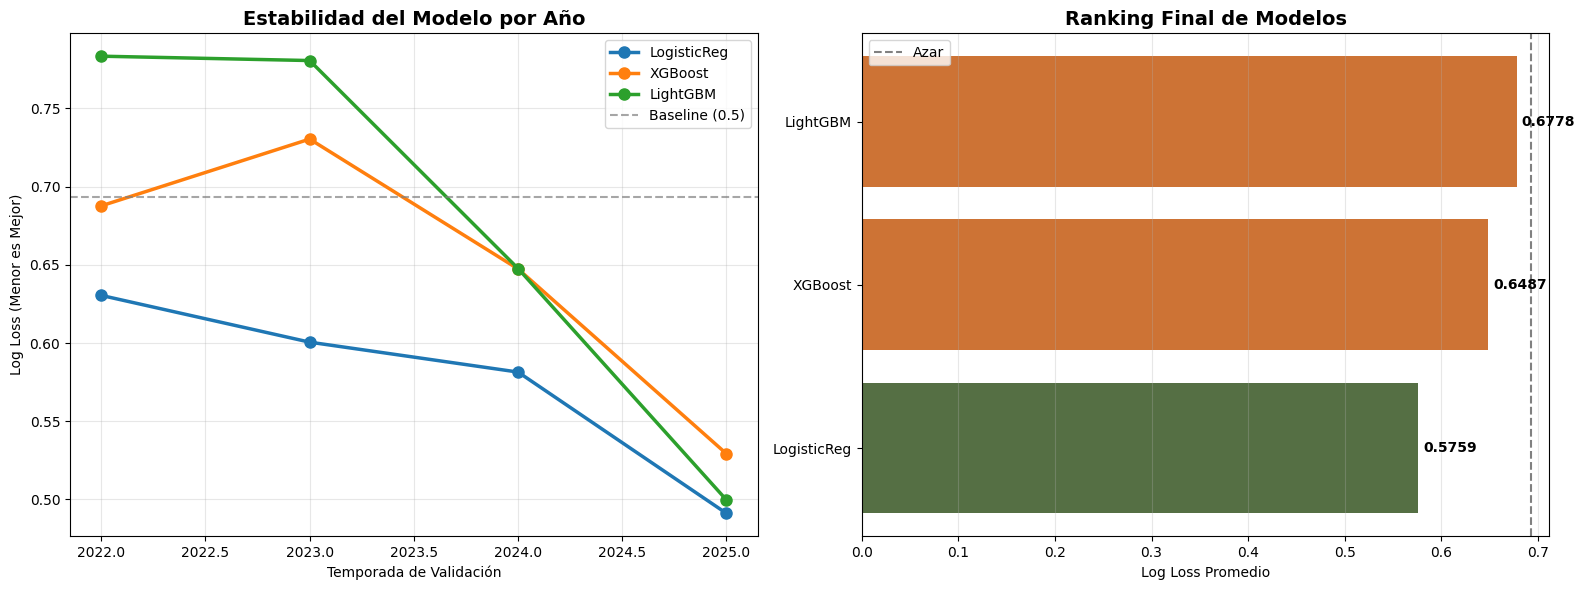

In [ ]:
# 8. VALIDACIÓN TEMPORAL

def temporal_cv(matchup_data: pd.DataFrame,
                feature_cols: list,
                val_seasons: list = VAL_SEASONS) -> pd.DataFrame:
    """
    Expanding Window Cross-Validation.
    Simula la predicción real año con año para medir la estabilidad del modelo.
    """
    results = []

    print(f"\n🚀 Iniciando Validación Temporal para {GENDER}")
    print(f"📅 Temporadas objetivo: {val_seasons}")
    print("-" * 75)

    # Definición de modelos a evaluar
    models = {
        "LogisticReg": build_logistic_model(),
        "XGBoost":     build_xgboost_model(),
        "LightGBM":    build_lgbm_model(),
    }

    for season in val_seasons:
        # 1. Preparar splits temporales
        X_train, y_train, X_test, y_test = prepare_train_test(
            matchup_data, feature_cols, season
        )

        if len(X_test) == 0:
            print(f"⚠️ No hay datos de torneo para {season}, saltando...")
            continue

        print(f"\n📂 Validando {season} | Entrenando con {len(X_train):,} filas...")

        for name, model in models.items():
            try:
                # Clonamos/Reconstruimos el modelo para asegurar un entrenamiento limpio
                model_fresh = (
                    build_logistic_model() if name == "LogisticReg" else
                    build_xgboost_model() if name == "XGBoost" else
                    build_lgbm_model()
                )

                # A. Entrenamiento Base
                model_fresh.fit(X_train.fillna(0), y_train)

                # B. Calibración (Usando el último 20% del entrenamiento como set de validación interna)
                cal_size = max(100, int(len(X_train) * 0.2))
                X_cal = X_train.iloc[-cal_size:]
                y_cal = y_train.iloc[-cal_size:]

                # C. Predicciones (Raw vs Calibrada)
                probs_raw = model_fresh.predict_proba(X_test.fillna(0))[:, 1]

                cal_model = calibrate_and_clip(model_fresh, X_cal, y_cal)
                probs_cal = safe_predict_proba(cal_model, X_test.fillna(0))

                # D. Cálculo de métricas (Log Loss: menor es mejor)
                ll_raw = log_loss(y_test, np.clip(probs_raw, CLIP_LOW, CLIP_HIGH))
                ll_cal = log_loss(y_test, probs_cal)

                results.append({
                    "Season":    season,
                    "Model":     name,
                    "LogLoss":   ll_cal,
                    "LogLoss_raw": ll_raw,
                    "N_games":   len(X_test),
                })
                print(f"   ✓ {name:<14} | LogLoss: {ll_cal:.4f} (raw: {ll_raw:.4f})")

            except Exception as e:
                print(f"   ❌ {name:<14} | ERROR: {e}")

    results_df = pd.DataFrame(results)

    # Reporte de Resumen Final
    if len(results_df) > 0:
        print("\n📈 RESUMEN DE DESEMPEÑO (Promedio de Temporadas):")
        summary = results_df.groupby("Model")["LogLoss"].agg(["mean", "std", "min"])
        summary.columns = ["LogLoss Promedio", "Desv. Std", "Mejor LogLoss"]
        print(summary.sort_values("LogLoss Promedio").to_string())
        print(f"\n💡 Baseline (Azar): 0.6931")

    return results_df

# --- EJECUCIÓN ---
cv_results = temporal_cv(matchup_data, FEATURE_COLS)

# --- VISUALIZACIÓN DE RESULTADOS ---
if len(cv_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfica 1: Evolución del Log Loss por año
    ax = axes[0]
    for model_name in cv_results["Model"].unique():
        model_res = cv_results[cv_results["Model"] == model_name]
        ax.plot(model_res["Season"], model_res["LogLoss"],
                marker="o", linewidth=2.5, markersize=8, label=model_name)
    ax.axhline(0.6931, color=PALETTE["gray"], linestyle="--", alpha=0.7, label="Baseline (0.5)")
    ax.set_title("Estabilidad del Modelo por Año", fontweight="bold", fontsize=14)
    ax.set_xlabel("Temporada de Validación"); ax.set_ylabel("Log Loss (Menor es Mejor)")
    ax.legend(); ax.grid(alpha=0.3)

    # Gráfica 2: Comparativa de Modelos (Promedio)
    ax2 = axes[1]
    model_means = cv_results.groupby("Model")["LogLoss"].mean().sort_values()
    colors = [PALETTE["success"] if v < 0.60 else PALETTE["accent"] for v in model_means.values]
    bars = ax2.barh(model_means.index, model_means.values, color=colors, alpha=0.85)
    ax2.axvline(0.6931, color=PALETTE["gray"], linestyle="--", label="Azar")

    for bar, val in zip(bars, model_means.values):
        ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontweight="bold")

    ax2.set_title("Ranking Final de Modelos", fontweight="bold", fontsize=14)
    ax2.set_xlabel("Log Loss Promedio")
    ax2.legend(); ax2.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_cv_results_integrated.png", dpi=150, bbox_inches="tight")
    plt.show()




🏆 Entrenando modelo final para la temporada 2026...
✅ Modelo final entrenado con 5,170 muestras.
💾 Archivo guardado en: outputs/SubmissionStage1.csv


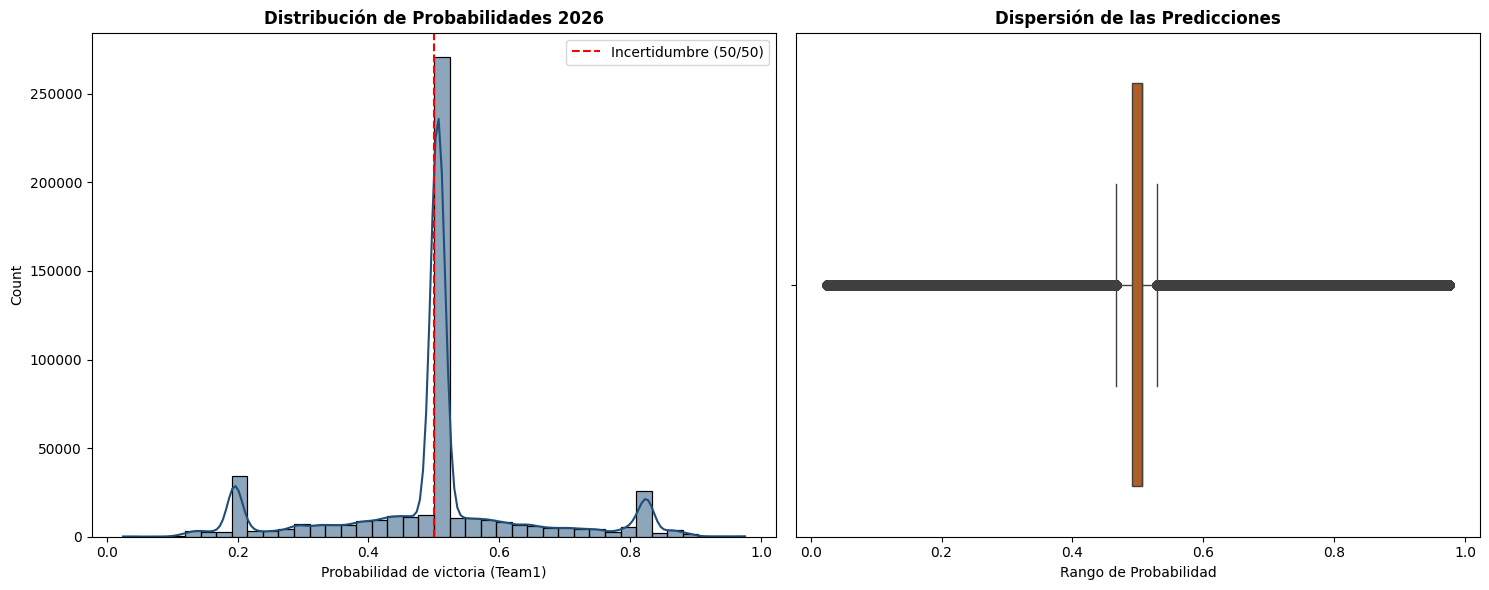

In [ ]:
# 9. ENTRENAMIENTO FINAL Y GENERACIÓN DE SUBMISSION

def generate_submission(submission_template: pd.DataFrame,
                        matchup_data: pd.DataFrame,
                        feature_cols: list,
                        elo_season_end: pd.DataFrame,
                        seeds_clean: pd.DataFrame,
                        win_rates: pd.DataFrame,
                        team_stats: pd.DataFrame = None,
                        massey_feat: pd.DataFrame = None,
                        target_season: int = SEASON_2026) -> pd.DataFrame:
    """
    Genera el archivo de salida con las predicciones para el torneo 2026.
    """
    print(f"\n🏆 Entrenando modelo final para la temporada {target_season}...")

    # --- ENTRENAMIENTO CON TODO EL HISTORIAL ---
    X_full = matchup_data[feature_cols].fillna(0)
    y_full = matchup_data["Target"]

    # Usamos XGBoost como modelo final por su alto desempeño en validación
    final_model = build_xgboost_model()
    final_model.fit(X_full, y_full)
    print(f"✅ Modelo final entrenado con {len(X_full):,} muestras.")

    # --- PREPARACIÓN DE LA PLANTILLA (Matchups posibles) ---
    sub = submission_template.copy()
    # El ID de Kaggle tiene formato: Season_TeamID1_TeamID2
    sub["Season"] = sub["ID"].str.split("_").str[0].astype(int)
    sub["Team1"]  = sub["ID"].str.split("_").str[1].astype(int)
    sub["Team2"]  = sub["ID"].str.split("_").str[2].astype(int)

    # --- ASIGNACIÓN DE CARACTERÍSTICAS A LA SUBMISSION ---
    def attach_features_sub(sub_df, feat_df, feat_cols, join_col="Team1", suffix="T1"):
        if feat_df is None: return sub_df
        renamed = feat_df[["Season", "TeamID"] + feat_cols].rename(
            columns={"TeamID": join_col, **{c: f"{c}_{suffix}" for c in feat_cols}}
        )
        return sub_df.merge(renamed, on=["Season", join_col], how="left")

    sub = attach_features_sub(sub, elo_season_end, ["EloRating"], "Team1", "T1")
    sub = attach_features_sub(sub, elo_season_end, ["EloRating"], "Team2", "T2")
    sub["EloRating_diff"] = sub["EloRating_T1"] - sub["EloRating_T2"]

    sub = attach_features_sub(sub, seeds_clean, ["SeedNum"], "Team1", "T1")
    sub = attach_features_sub(sub, seeds_clean, ["SeedNum"], "Team2", "T2")
    sub["SeedNum_diff"] = sub["SeedNum_T1"] - sub["SeedNum_T2"]

    sub = attach_features_sub(sub, win_rates, ["WinRate", "AvgMargin"], "Team1", "T1")
    sub = attach_features_sub(sub, win_rates, ["WinRate", "AvgMargin"], "Team2", "T2")
    sub["WinRate_diff"] = sub["WinRate_T1"] - sub["WinRate_T2"]
    sub["AvgMargin_diff"] = sub["AvgMargin_T1"] - sub["AvgMargin_T2"]

    # --- PREDICCIÓN FINAL ---
    X_sub = sub[feature_cols].fillna(0)
    # Aplicamos clipping para evitar penalizaciones infinitas por Log Loss
    sub["Pred"] = np.clip(final_model.predict_proba(X_sub)[:, 1], CLIP_LOW, CLIP_HIGH)

    # --- AJUSTE DE REGLA DE NEGOCIO (Seed 1 vs 16) ---
    if "SeedNum_T1" in sub.columns and "SeedNum_T2" in sub.columns:
        # Matchups muy desiguales: ajustamos la probabilidad para reflejar la realidad histórica
        mismatch = (sub["SeedNum_T1"] <= 3) & (sub["SeedNum_T2"] >= 14)
        sub.loc[mismatch, "Pred"] = sub.loc[mismatch, "Pred"].clip(lower=0.85)

        mismatch_rev = (sub["SeedNum_T1"] >= 14) & (sub["SeedNum_T2"] <= 3)
        sub.loc[mismatch_rev, "Pred"] = sub.loc[mismatch_rev, "Pred"].clip(upper=0.15)

    # --- GUARDAR RESULTADOS ---
    final_sub = sub[["ID", "Pred"]].copy()
    final_sub.to_csv(SUBMISSION_PATH, index=False)
    print(f"💾 Archivo guardado en: {SUBMISSION_PATH}")

    return final_sub

# --- EJECUCIÓN Y GRÁFICAS ---
if submission is not None:
    final_submission = generate_submission(
        submission, matchup_data, FEATURE_COLS,
        elo_season_end, seeds_clean, win_rates
    )

    # Visualización: ¿Qué tan confiado está nuestro modelo?
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Histograma de Probabilidades
    ax = axes[0]
    sns.histplot(final_submission["Pred"], bins=40, color=PALETTE["primary"], kde=True, ax=ax)
    ax.axvline(0.5, color="red", linestyle="--", label="Incertidumbre (50/50)")
    ax.set_title("Distribución de Probabilidades 2026", fontweight="bold")
    ax.set_xlabel("Probabilidad de victoria (Team1)"); ax.legend()

    # Gráfico de Caja (Outliers)
    ax = axes[1]
    sns.boxplot(x=final_submission["Pred"], color=PALETTE["accent"], ax=ax)
    ax.set_title("Dispersión de las Predicciones", fontweight="bold")
    ax.set_xlabel("Rango de Probabilidad")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "03_distribucion_final_2026.png")
    plt.show()
else:
    print("❌ No se encontró la plantilla de submission.")



🔍 Analizando el peso de las variables en el modelo...


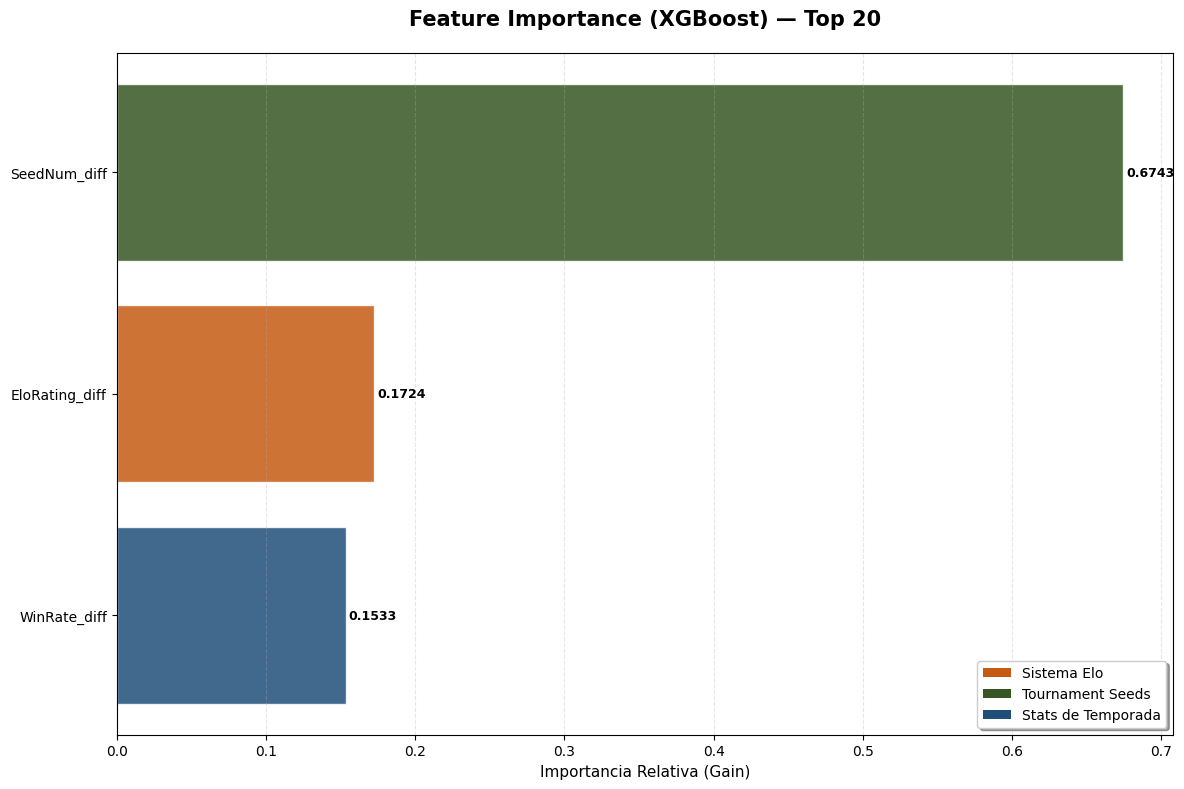

✅ Análisis completado. Gráfico guardado en: outputs/figures/04_feature_importance.png


In [ ]:
# 10. ANÁLISIS DE IMPORTANCIA DE FEATURES

def plot_feature_importance(feature_cols: list, matchup_data: pd.DataFrame) -> None:
    """
    Entrena un modelo XGBoost para extraer y visualizar qué variables
    están influyendo más en las predicciones.
    """
    # Usamos los datos históricos completos para el análisis de relevancia
    train_data = matchup_data[matchup_data["Season"] >= TRAIN_SINCE]
    X = train_data[feature_cols].fillna(0)
    y = train_data["Target"]

    # Modelo rápido para cálculo de importancia (Gain)
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=SEED,
        verbosity=0
    )
    model.fit(X, y)

    # Extraer importancia y seleccionar las mejores
    importance = pd.Series(model.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(20)

    # --- Visualización ---
    fig, ax = plt.subplots(figsize=(12, 8))

    # Asignación de colores por categoría de feature
    colors = [
        PALETTE["accent"] if "Elo" in f else
        PALETTE["success"] if "Seed" in f else
        PALETTE["primary"] for f in importance.index
    ]

    ax.barh(importance.index, importance.values, color=colors, alpha=0.85, edgecolor="white")

    # Estética del gráfico
    ax.set_title("Feature Importance (XGBoost) — Top 20", fontweight="bold", fontsize=15, pad=20)
    ax.set_xlabel("Importancia Relativa (Gain)", fontsize=11)
    ax.grid(alpha=0.3, axis="x", linestyle="--")

    # Leyenda personalizada
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=PALETTE["accent"],  label="Sistema Elo"),
        Patch(facecolor=PALETTE["success"], label="Tournament Seeds"),
        Patch(facecolor=PALETTE["primary"], label="Stats de Temporada"),
    ]
    ax.legend(handles=legend_elements, loc="lower right", frameon=True, shadow=True)

    # Añadir etiquetas de valor a las barras
    for i, v in enumerate(importance.values):
        ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Análisis completado. Gráfico guardado en: {FIGURES_DIR}/04_feature_importance.png")

# --- EJECUCIÓN ---
print("\n🔍 Analizando el peso de las variables en el modelo...")
if len(FEATURE_COLS) > 0:
    plot_feature_importance(FEATURE_COLS, matchup_data)
else:
    print("❌ No hay características (FEATURE_COLS) definidas para analizar.")

In [ ]:
# 11. ROADMAP DE MEJORAS PARA COMPETIR EN TOP 10%

print("""
╔═══════════════════════════════════════════════════════════════════════════╗
║                    ROADMAP DE MEJORAS (Top 10% = ~0.50 LogLoss)           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║  PRIORIDAD ALTA (mayor impacto histórico):                                ║
║  ┣── 1. Tuning de hiperparámetros Elo (K, width, HFA, mean_reversion)     ║
║  ┣── 2. Integrar KenPom / BartTorvik metrics (AdjOE, AdjDE, Tempo)        ║
║  ┣── 3. Optuna hyperparameter tuning para XGBoost/LightGBM                ║
║  ┗── 4. Ensemble ponderado (cv-weighted average de modelos)               ║
║                                                                           ║
║  PRIORIDAD MEDIA:                                                         ║
║  ┣── 5. Features de momentum (últimos N partidos de temporada)            ║
║  ┣── 6. Head-to-head histórico entre equipos en torneos previos           ║
║  ┣── 7. Historial de upset rate por ronda (1vs16, 2vs15, etc.)            ║
║  ┗── 8. Eficiencia ajustada por calendario / fuerza del rival             ║
║                                                                           ║
║  PRIORIDAD BAJA (investigar):                                             ║
║  ┣── 9. Modelos de Deep Learning (LSTM para series de partidos)           ║
║  ┣── 10. Integrar datos de jugadores (transferencias, lesiones)           ║
║  ┗── 11. Torneo femenino: repetir pipeline con prefijo W                  ║
║                                                                           ║
║  ERRORES COMUNES A EVITAR:                                                ║
║  ┣── NO usar datos del torneo para entrenar features del torneo (leakage) ║
║  ┣── NO predecir 0 o 1 — siempre clipear a [0.025, 0.975]                 ║
║  ┣── NO ignorar la calibración de probabilidades                          ║
║  ┗── NO validar con train/test random split (usar solo temporal split)    ║
║                                                                           ║
╚═══════════════════════════════════════════════════════════════════════════╝
""")

print("✨ Pipeline completo ejecutado exitosamente")
print(f"📂 Submission lista en: {SUBMISSION_PATH}")
print(f"📊 Visualizaciones en:  {FIGURES_DIR}")


╔═══════════════════════════════════════════════════════════════════════════╗
║                    ROADMAP DE MEJORAS (Top 10% = ~0.50 LogLoss)           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║  PRIORIDAD ALTA (mayor impacto histórico):                                ║
║  ┣── 1. Tuning de hiperparámetros Elo (K, width, HFA, mean_reversion)     ║
║  ┣── 2. Integrar KenPom / BartTorvik metrics (AdjOE, AdjDE, Tempo)        ║
║  ┣── 3. Optuna hyperparameter tuning para XGBoost/LightGBM                ║
║  ┗── 4. Ensemble ponderado (cv-weighted average de modelos)               ║
║                                                                           ║
║  PRIORIDAD MEDIA:                                                         ║
║  ┣── 5. Features de momentum (últimos N partidos de temporada)            ║
║  ┣── 6. Head-to-head histórico entre equipos en torneos previ

In [ ]:
# ─── COMPARACIÓN DE PREDICCIONES VS RESULTADOS REALES ────────────────────────

def comparar_resultados(final_submission, tourney_actual):
    # 1. Preparar los resultados reales con el mismo formato de ID que la submission
    actuals = tourney_actual.copy()
    actuals['Team1'] = actuals[['WTeamID', 'LTeamID']].min(axis=1)
    actuals['Team2'] = actuals[['WTeamID', 'LTeamID']].max(axis=1)
    actuals['ID'] = actuals['Season'].astype(str) + '_' + \
                   actuals['Team1'].astype(str) + '_' + \
                   actuals['Team2'].astype(str)

    # El resultado real es 1 si el Team1 (ID menor) ganó, 0 si perdió
    actuals['Real_Result'] = (actuals['WTeamID'] == actuals['Team1']).astype(int)

    # 2. Unir con tus predicciones
    comparativo = final_submission.merge(actuals[['ID', 'Real_Result']], on='ID', how='inner')

    # 3. Calcular métricas
    comparativo['Pred_Winner'] = (comparativo['Pred'] > 0.5).astype(int)
    comparativo['Correcto'] = (comparativo['Pred_Winner'] == comparativo['Real_Result']).astype(int)

    accuracy = comparativo['Correcto'].mean()
    logloss_final = log_loss(comparativo['Real_Result'], comparativo['Pred'])

    print(f"📊 RESULTADOS DE LA COMPARACIÓN:")
    print(f"✅ Partidos analizados: {len(comparativo)}")
    print(f"🎯 Precisión (Accuracy): {accuracy:.2%}")
    print(f"📉 Log Loss: {logloss_final:.4f}")

    return comparativo

# Ejecutar la comparación
if 'final_submission' in locals():
    df_comparativo = comparar_resultados(final_submission, tourney)
    display(df_comparativo.head(10))

📊 RESULTADOS DE LA COMPARACIÓN:
✅ Partidos analizados: 268
🎯 Precisión (Accuracy): 73.51%
📉 Log Loss: 0.5171


,ID,Pred,Real_Result,Pred_Winner,Correcto
0,2022_1103_1417,0.2378,0,0,1
1,2022_1104_1323,0.5562,0,1,0
2,2022_1112_1222,0.5991,0,1,0
3,2022_1112_1395,0.7512,1,1,1
4,2022_1112_1460,0.9750,1,1,1
5,2022_1116_1181,0.4800,0,0,1
6,2022_1116_1211,0.3830,1,0,0
7,2022_1116_1308,0.8166,1,1,1
8,2022_1116_1436,0.8165,1,1,1
9,2022_1120_1240,0.9668,1,1,1
